<a href="https://colab.research.google.com/github/Zamorano86/UFRJ_MESTRADO_ENG_NAVAL/blob/main/Lista2_Acustica_Submarina.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Propriedades dos meios
rho1 = 1025      # kg/m³ - água do mar
c1 = 1500        # m/s

rho2 = 1800      # kg/m³ - fundo
c2 = 2000        # m/s

# Impedâncias acústicas
Z1 = rho1 * c1
Z2 = rho2 * c2

# Ângulo crítico
theta_c = np.arcsin(c1/c2)
theta_c_deg = np.degrees(theta_c)

print(f"Z1 = {Z1:.2f} kg/(m².s)")
print(f"Z2 = {Z2:.2f} kg/(m².s)")
print(f"Ângulo crítico = {theta_c_deg:.2f} graus")

# Ângulos até pouco antes do crítico
theta_i_deg = np.linspace(0, theta_c_deg - 0.001, 1000)
theta_i = np.radians(theta_i_deg)

# Lei de Snell
sin_theta_t = (c2/c1) * np.sin(theta_i)
theta_t = np.arcsin(sin_theta_t)

# Coeficiente de reflexão de pressão
r = (
    Z2*np.cos(theta_i) - Z1*np.cos(theta_t)
) / (
    Z2*np.cos(theta_i) + Z1*np.cos(theta_t)
)

# Coeficientes de energia
R = np.abs(r)**2
T = 1 - R

Z1 = 1537500.00 kg/(m².s)
Z2 = 3600000.00 kg/(m².s)
Ângulo crítico = 48.59 graus


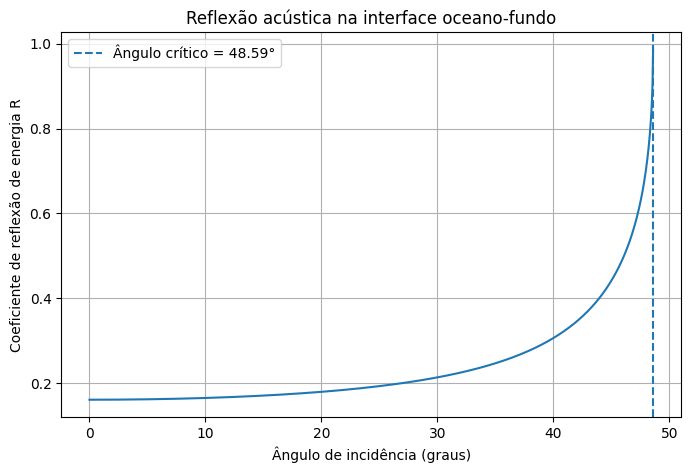

In [2]:
plt.figure(figsize=(8,5))

plt.plot(theta_i_deg, R)
plt.axvline(theta_c_deg, linestyle='--',
            label=f'Ângulo crítico = {theta_c_deg:.2f}°')

plt.xlabel('Ângulo de incidência (graus)')
plt.ylabel('Coeficiente de reflexão de energia R')
plt.title('Reflexão acústica na interface oceano-fundo')
plt.grid(True)
plt.legend()

plt.show()

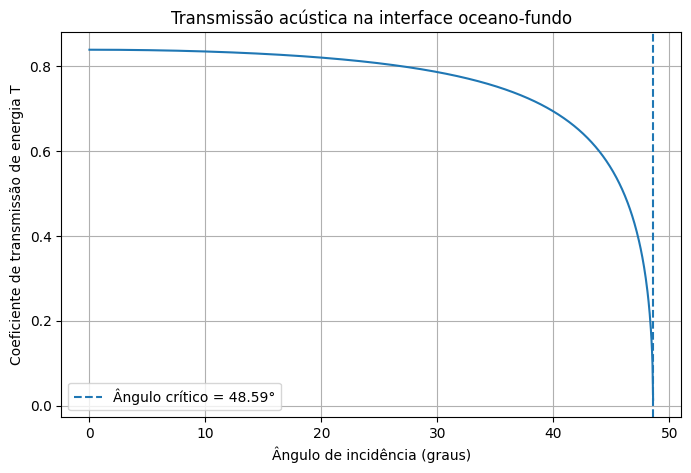

In [3]:
plt.figure(figsize=(8,5))

plt.plot(theta_i_deg, T)
plt.axvline(theta_c_deg, linestyle='--',
            label=f'Ângulo crítico = {theta_c_deg:.2f}°')

plt.xlabel('Ângulo de incidência (graus)')
plt.ylabel('Coeficiente de transmissão de energia T')
plt.title('Transmissão acústica na interface oceano-fundo')
plt.grid(True)
plt.legend()

plt.show()

In [4]:
import pandas as pd
import numpy as np

# Ângulos escolhidos para a tabela
angulos = np.array([0, 10, 20, 30, 40, 45, 48], dtype=float)

theta_i_tab = np.radians(angulos)

# Lei de Snell
sin_theta_t_tab = (c2/c1) * np.sin(theta_i_tab)
theta_t_tab = np.arcsin(sin_theta_t_tab)

# Coeficiente de reflexão de pressão
r_tab = (
    Z2*np.cos(theta_i_tab) - Z1*np.cos(theta_t_tab)
) / (
    Z2*np.cos(theta_i_tab) + Z1*np.cos(theta_t_tab)
)

# Coeficientes energéticos
R_tab = np.abs(r_tab)**2
T_tab = 1 - R_tab

# Tabela
tabela = pd.DataFrame({
    "θ_i (graus)": angulos,
    "θ_t (graus)": np.degrees(theta_t_tab),
    "r": r_tab,
    "R": R_tab,
    "T": T_tab
})

tabela = tabela.round({
    "θ_i (graus)": 2,
    "θ_t (graus)": 2,
    "r": 4,
    "R": 4,
    "T": 4
})

display(tabela)

print("\nTabela em LaTeX:\n")
print(tabela.to_latex(index=False))

,θ_i (graus),θ_t (graus),r,R,T
0,0.0,0.00,0.4015,0.1612,0.8388
1,10.0,13.39,0.4066,0.1653,0.8347
2,20.0,27.13,0.4240,0.1798,0.8202
3,30.0,41.81,0.4624,0.2139,0.7861
4,40.0,58.99,0.5537,0.3066,0.6934
5,45.0,70.53,0.6648,0.4420,0.5580
6,48.0,82.25,0.8415,0.7080,0.2920



Tabela em LaTeX:

\begin{tabular}{rrrrr}
\toprule
θ_i (graus) & θ_t (graus) & r & R & T \\
\midrule
0.000000 & 0.000000 & 0.401500 & 0.161200 & 0.838800 \\
10.000000 & 13.390000 & 0.406600 & 0.165300 & 0.834700 \\
20.000000 & 27.130000 & 0.424000 & 0.179800 & 0.820200 \\
30.000000 & 41.810000 & 0.462400 & 0.213900 & 0.786100 \\
40.000000 & 58.990000 & 0.553700 & 0.306600 & 0.693400 \\
45.000000 & 70.530000 & 0.664800 & 0.442000 & 0.558000 \\
48.000000 & 82.250000 & 0.841500 & 0.708000 & 0.292000 \\
\bottomrule
\end{tabular}



Z1 = 1537500.00 kg/(m².s)
Z2 = 3600000.00 kg/(m².s)
Ângulo crítico = 48.59 graus

Verificação da conservação de energia na região subcrítica:
Máximo |R + T - 1| = 4.441e-16


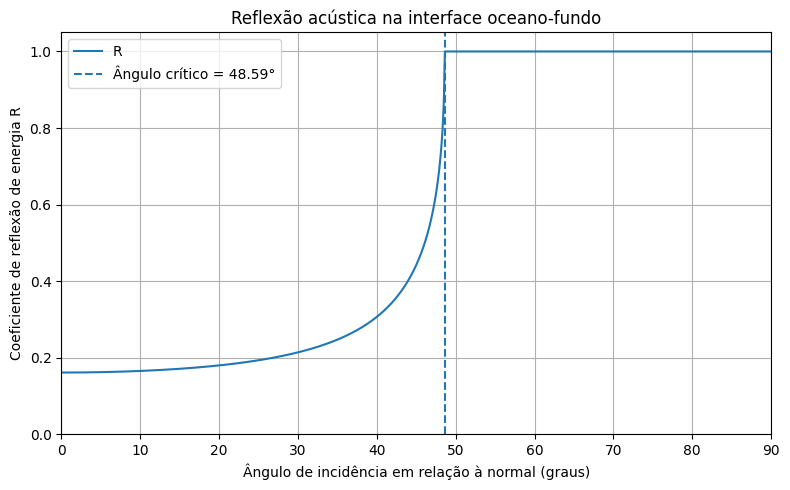

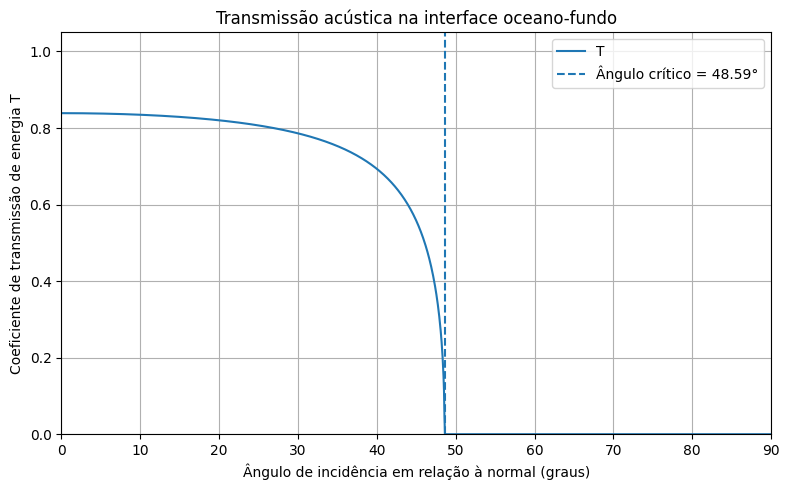

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# PARÂMETROS
# ---------------------------------------------------------

rho1 = 1025.0      # kg/m³ - água do mar
c1   = 1500.0      # m/s

rho2 = 1800.0      # kg/m³ - fundo como fluido equivalente
c2   = 2000.0      # m/s

Z1 = rho1 * c1
Z2 = rho2 * c2

# Ângulo crítico medido em relação à normal
theta_c = np.arcsin(c1 / c2)
theta_c_deg = np.degrees(theta_c)

# Ângulos de incidência: 0 a 90 graus
theta_i_deg = np.linspace(0.0, 89.9, 1500)
theta_i = np.radians(theta_i_deg)

# ---------------------------------------------------------
# COEFICIENTES DE ENERGIA
# ---------------------------------------------------------

R = np.ones_like(theta_i)
T = np.zeros_like(theta_i)

# Região subcrítica
mask = theta_i < theta_c

sin_theta_t = (c2 / c1) * np.sin(theta_i[mask])
theta_t = np.arcsin(sin_theta_t)

r = (
    Z2 * np.cos(theta_i[mask])
    - Z1 * np.cos(theta_t)
) / (
    Z2 * np.cos(theta_i[mask])
    + Z1 * np.cos(theta_t)
)

R[mask] = np.abs(r)**2

# Expressão energética explícita
T[mask] = (
    4 * Z1 * Z2
    * np.cos(theta_i[mask])
    * np.cos(theta_t)
    /
    (
        Z2 * np.cos(theta_i[mask])
        + Z1 * np.cos(theta_t)
    )**2
)

# Na região crítica/supercrítica ideal:
# R = 1 e T = 0

print(f"Z1 = {Z1:.2f} kg/(m².s)")
print(f"Z2 = {Z2:.2f} kg/(m².s)")
print(f"Ângulo crítico = {theta_c_deg:.2f} graus")

print("\nVerificação da conservação de energia na região subcrítica:")
print(f"Máximo |R + T - 1| = {np.max(np.abs(R[mask] + T[mask] - 1)):.3e}")

# ---------------------------------------------------------
# GRÁFICO DE REFLEXÃO
# ---------------------------------------------------------

plt.figure(figsize=(8,5))

plt.plot(theta_i_deg, R, label="R")
plt.axvline(
    theta_c_deg,
    linestyle="--",
    label=f"Ângulo crítico = {theta_c_deg:.2f}°"
)

plt.xlabel("Ângulo de incidência em relação à normal (graus)")
plt.ylabel("Coeficiente de reflexão de energia R")
plt.title("Reflexão acústica na interface oceano-fundo")
plt.xlim(0, 90)
plt.ylim(0, 1.05)
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.savefig("1_Reflexao_completa.png", dpi=300, bbox_inches="tight")
plt.show()

# ---------------------------------------------------------
# GRÁFICO DE TRANSMISSÃO
# ---------------------------------------------------------

plt.figure(figsize=(8,5))

plt.plot(theta_i_deg, T, label="T")
plt.axvline(
    theta_c_deg,
    linestyle="--",
    label=f"Ângulo crítico = {theta_c_deg:.2f}°"
)

plt.xlabel("Ângulo de incidência em relação à normal (graus)")
plt.ylabel("Coeficiente de transmissão de energia T")
plt.title("Transmissão acústica na interface oceano-fundo")
plt.xlim(0, 90)
plt.ylim(0, 1.05)
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.savefig("2_Transmissao_completa.png", dpi=300, bbox_inches="tight")
plt.show()